<a href="https://www.kaggle.com/code/joechapa/portfolio-project-clustering-customer-behavior?scriptVersionId=326108853" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Designing Credit Card Rewards Around Real Customer Behavior
## A Data-Driven Approach to Product Design

### The Inspiration
This analysis was sparked by recent shifts in the FinTech rewards space. As products move toward more lifestyle-integrated experiences, they face a classic Product Management challenge: **How do you balance sustainable unit economics with a reward structure users actually find intuitive?**

### Key Insight
Reward tiers should emerge from behavior, not be imposed on it.

### Objective
To demonstrate how clustering and simulation can simplify a complex product catalog into a three-tier offering that serves every customer segment. Specifically, we will:
1. **Identify** distinct behavioral segments from real transaction data.
2. **Simulate** reward payouts across different card structures.
3. **Recommend** a streamlined product portfolio that maximizes customer value while remaining profitable for the issuer.

---

# Phase 0: The Design Challenge

Most credit cards are built around *who* a customer is — demographics like income or credit score — rather than *what* they actually do. This creates a relevance gap: a high-income traveler and a high-income homebody might be offered the same card, even though their daily needs are completely different.

**The Hypothesis:** By segmenting users based on their spending signature — the specific patterns of where and how their money moves — we can design a leaner, more intuitive product catalog that feels personal to the user while remaining operationally simple for the issuer.


In [1]:
#import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Standardize visuals
sns.set_theme(style="whitegrid", palette="muted")

# Load data (using the standard Kaggle path/placeholder)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
df = pd.read_csv(r"/kaggle/input/credit-card-transactions/transactions.csv")

import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


/kaggle/input/credit-card-transactions/transactions.csv


In [2]:
df.head(10)

,accountNumber,creditLimit,availableMoney,transactionDateTime,merchantName,transactionAmount,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,currentBalance,cardPresent,expirationDateKeyInMatch,isFraud
0,737265056,5000,5000.00,2016-08-13T14:27:32,Uber,98.55,US,US,2.0,1.0,...,3/14/2015,3/14/2015,414,414,1803,PURCHASE,0.00,0,0,0
1,737265056,5000,5000.00,2016-10-11T05:05:54,AMC #191138,74.51,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.00,1,0,0
2,737265056,5000,5000.00,2016-11-08T09:18:39,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.00,0,0,0
3,737265056,5000,5000.00,2016-12-10T02:14:50,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.00,0,0,0
4,830329091,5000,5000.00,2016-03-24T21:04:46,Tim Hortons #947751,71.18,US,US,2.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.00,1,0,0
5,830329091,5000,5000.00,2016-04-19T16:24:27,In-N-Out #422833,30.76,US,US,2.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.00,1,0,0
6,830329091,5000,5000.00,2016-05-21T14:50:35,Krispy Kreme #685312,57.28,US,US,2.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.00,1,0,0
7,830329091,5000,5000.00,2016-06-03T00:31:21,Shake Shack #968081,9.37,US,US,5.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.00,1,0,0
8,830329091,5000,4990.63,2016-06-10T01:21:46,Burger King #486122,523.67,NaN,US,2.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,9.37,1,0,0
9,830329091,5000,5000.00,2016-07-11T10:47:16,Five Guys #510989,164.37,US,US,5.0,8.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.00,1,0,0


# Phase 1: Dataset Review & Signal Validation
Before we can design a product, we must understand the raw material. In this phase, we audit our transaction data to confirm we have a clean behavioral signal. We aren't just looking for missing values, but validating that the patterns we see are meaningful.

**The Dataset Profile:**
- **Users:** 5,000 unique accounts.
- **Scope:** Multi-category transaction data (Dining, Travel, Retail, etc.).
- **Key Metrics:** Transaction frequency, merchant diversity, and spend intensity.

---

### Data Audit

We begin by inspecting the raw transactions. While the dataset includes metadata columns like `posEntryMode`, our analysis focuses on **where** money is spent (`merchantCategoryCode`) and **how much** (`transactionAmount`). The chart below shows which categories have the most activity — this is the landscape our reward structure needs to address.

Total Transactions: 786363
Unique Users: 5000


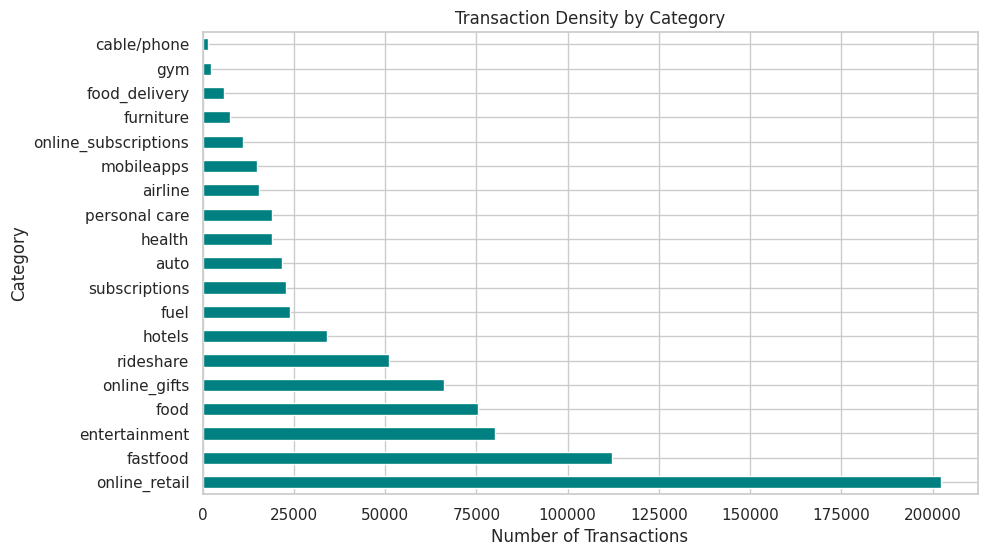

Missing Data Summary:
acqCountry             4562
merchantCountryCode     724
posEntryMode           4054
posConditionCode        409
transactionType         698
dtype: int64


In [3]:
# 1. Summary of the cohort
print(f"Total Transactions: {df.shape[0]}")
print(f"Unique Users: {df['accountNumber'].nunique()}")

# 2. Visualizing the "Center of Gravity"
# This shows us which categories 'matter' most for the reward structure
plt.figure(figsize=(10, 6))
df['merchantCategoryCode'].value_counts().plot(kind='barh', color='teal')
plt.title('Transaction Density by Category')
plt.xlabel('Number of Transactions')
plt.ylabel('Category')
plt.show()

# 3. Quick check for data health
# Product Decision: We see nulls in 'acqCountry' and 'posEntryMode'. 
# Since our model relies on merchantCategoryCode (which is 100% present), 
# these missing metadata tags won't impact our behavioral clustering.
null_counts = df.isnull().sum()[df.isnull().sum() > 0]
print("Missing Data Summary:")
print(null_counts)

### Refining the Cohort

To build a reliable behavioral signature, we need users with enough transaction history. A single purchase doesn't tell us anything about lifestyle.

> **Design Decision:** We filter for users with at least 5 transactions. This ensures every segment reflects an established habit, not a one-off purchase.

In [4]:
# Filtering for users with a minimum transaction history
min_txns = 5
user_counts = df.groupby('accountNumber').size()
active_users = user_counts[user_counts >= min_txns].index
df_clean = df[df['accountNumber'].isin(active_users)].copy()

print(f"Users retained for clustering: {len(active_users)}")
print(f"Data retention: {len(df_clean)/len(df) * 100:.2f}% of total transactions")

Users retained for clustering: 4844
Data retention: 99.95% of total transactions


### Quality Check: Strong Signal, Minimal Attrition

We retained **99.95%** of total transactions after filtering. That high retention rate tells us something meaningful on its own: nearly every user in this dataset already has an established transaction history. We are not cherry-picking a small, unrepresentative subset — we are designing for the natural shape of the customer base.

With a clean cohort of **4,844 users**, we are ready to build behavioral signatures.


# Phase 2: Feature Engineering — The Behavioral Signature

A transaction log tells us what happened. A behavioral signature tells us who someone is.

In this phase, we transform raw transactions into per-user features that capture two dimensions:
- **Lifestyle** — which categories a user spends in, expressed as a share of their total wallet
- **Financial Intensity** — how much they spend and how consistently

> **Design Decision:** We represent spending categories as **percentages of total spend** rather than raw dollar amounts. This lets us identify users with the same lifestyle regardless of income — a student and a high-earner who both allocate 40% of their wallet to dining share the same behavioral profile, even if the absolute dollars differ.

### Feature Exploration

Below, we calculate the full feature set and validate its diversity using a correlation heatmap. Low correlation between lifestyle features (e.g., `perc_online_retail`) and intensity features (e.g., `monthly_spend_volatility`) confirms that *what* someone buys is genuinely distinct from *how consistently* they buy. Both dimensions are worth keeping.


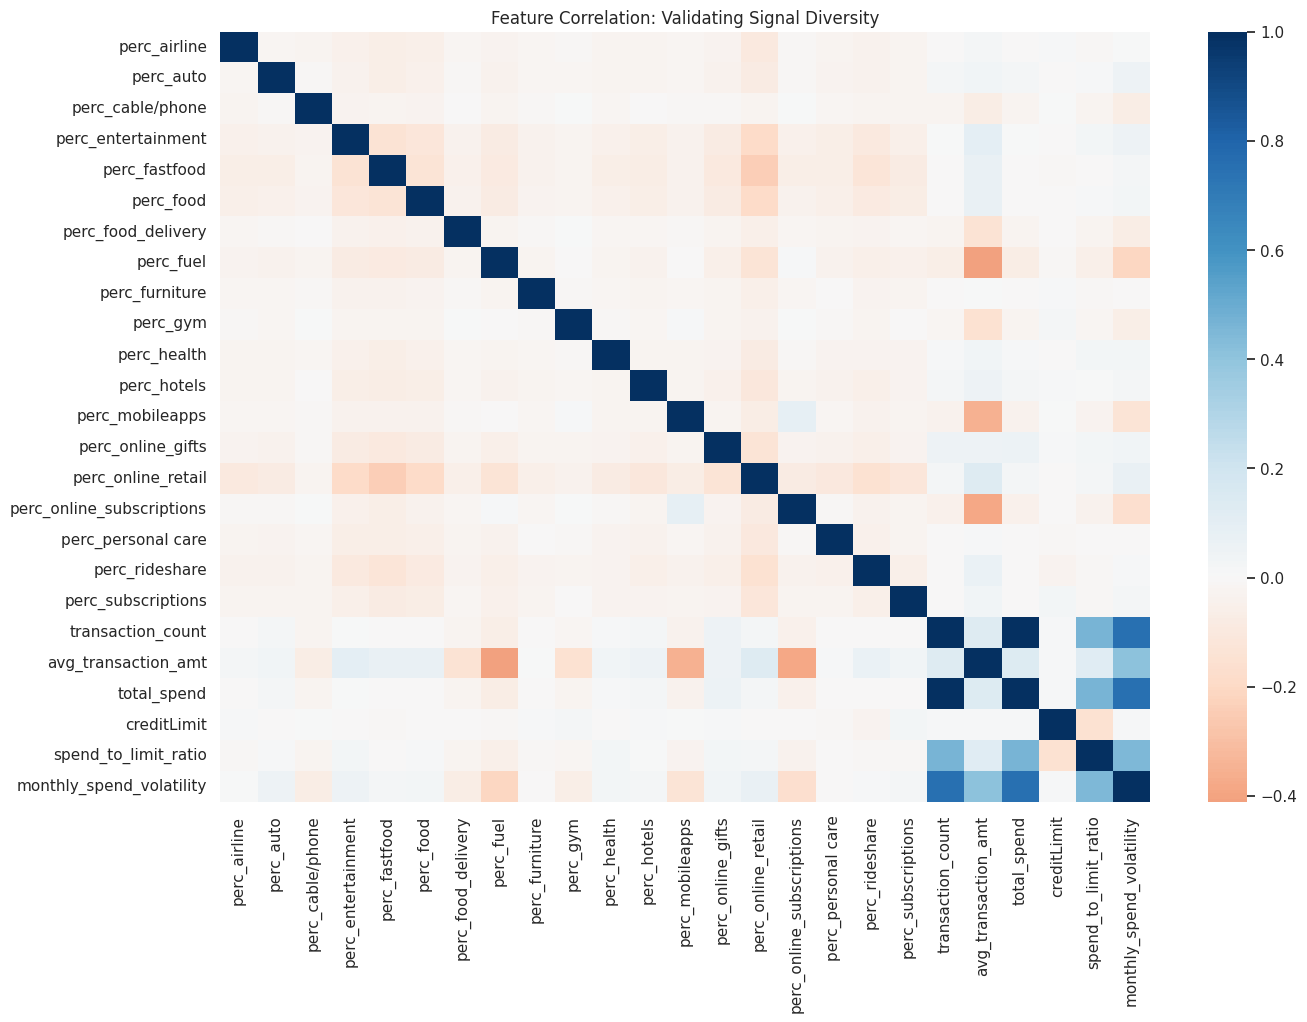

In [5]:
# Phase 2: Feature Engineering (The Behavioral Signature)
# --------------------------------------------------------

# Ensure df_clean is a proper copy to avoid warnings when creating new columns
df_clean = df_clean.copy()

# 1. Create Temporal Features
# We need 'Month' to calculate volatility (habit consistency)
df_clean['transactionDateTime'] = pd.to_datetime(df_clean['transactionDateTime'])
df_clean['transactionMonth'] = df_clean['transactionDateTime'].dt.to_period('M')

# 2. Calculate Lifestyle Features (Percentages)
# Normalizing spend by category to group users by 'lifestyle' rather than 'wealth'
cat_spend = df_clean.groupby(['accountNumber', 'merchantCategoryCode'])['transactionAmount'].sum().unstack(fill_value=0)
total_spend = cat_spend.sum(axis=1)
cat_percent = cat_spend.div(total_spend, axis=0)
cat_percent.columns = [f'perc_{col}' for col in cat_percent.columns]

# 3. Calculate Intensity Features (Financial Habits)
credit_limit = df_clean.groupby('accountNumber')['creditLimit'].first()
txn_count = df_clean.groupby('accountNumber')['transactionAmount'].count().rename('transaction_count')
avg_txn = df_clean.groupby('accountNumber')['transactionAmount'].mean().rename('avg_transaction_amt')

# Monthly spend and Volatility (Std Dev of monthly totals)
monthly_spend_totals = df_clean.groupby(['accountNumber', 'transactionMonth'])['transactionAmount'].sum().reset_index()
volatility = monthly_spend_totals.groupby('accountNumber')['transactionAmount'].std().rename('monthly_spend_volatility').fillna(0)

# 4. Merge into final behavioral dataframe
final_df = pd.concat([
    cat_percent, 
    txn_count, 
    avg_txn, 
    total_spend.rename('total_spend'),
    credit_limit,
    (total_spend / credit_limit).rename('spend_to_limit_ratio'),
    volatility
], axis=1).fillna(0)

# --- Visual Validation ---
plt.figure(figsize=(15, 10))
# Focusing the heatmap on the core behavioral and financial features
sns.heatmap(final_df.corr(), cmap='RdBu', center=0, annot=False) 
plt.title('Feature Correlation: Validating Signal Diversity')
plt.show()

# Product Decision Callout: 
# The low correlation between merchant categories (e.g., perc_online_retail) and 
# monthly_spend_volatility confirms that 'what' someone buys is distinct from 
# 'how consistently' they buy. We will keep both to build multi-dimensional personas.

### Feature Scaling

K-Means clusters by minimizing Euclidean distance. Without scaling, features with large numeric ranges — like `total_spend` — would dominate the distance calculation and drown out proportional features like `perc_dining`. We apply `StandardScaler` to give every feature an equal vote in the final clustering.


In [6]:
# Scaling all features for optimal K-Means performance
scaler = StandardScaler()
scaled_features = scaler.fit_transform(final_df)

# Create a DataFrame of scaled values for reference
cluster_input = pd.DataFrame(scaled_features, columns=final_df.columns, index=final_df.index)

print(f"Feature matrix ready for clustering. Shape: {cluster_input.shape}")

Feature matrix ready for clustering. Shape: (4844, 25)


# Phase 3: Unsupervised Clustering

With a clean, scaled feature matrix, we can let the data speak for itself. K-Means will find the natural groupings in our 4,844-user cohort without any predetermined labels.

## 3.1 Choosing the Number of Clusters (k)

We evaluate k using two complementary metrics:
- **Elbow Method:** Finds the point of diminishing returns in variance reduction as k increases.
- **Silhouette Score:** Measures how well-separated each cluster is from its neighbors. Higher is better.

> **Data Handling Note:** A small number of users had no spend in certain niche categories. We imputed these with `0` — the absence of a category in someone's transaction history means their spend percentage in that category is genuinely zero.


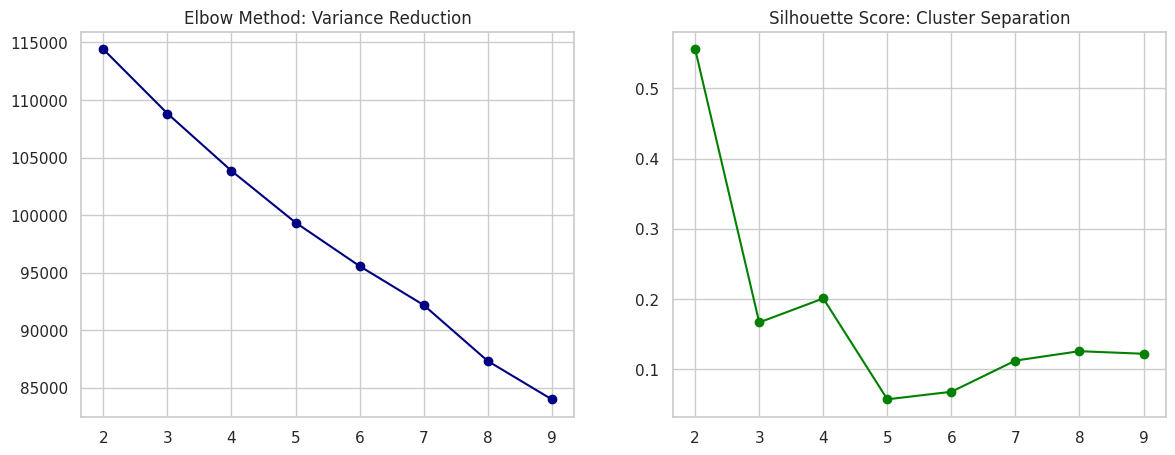

In [7]:
# Final safety check: replace any remaining NaNs with 0
cluster_input = cluster_input.fillna(0)

# KMeans evaluation loop
inertias, silhouettes = [], []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(cluster_input)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(cluster_input, labels))

# Plotting results
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(K_range, inertias, marker='o', color='navy')
ax[0].set_title('Elbow Method: Variance Reduction')
ax[1].plot(K_range, silhouettes, marker='o', color='green')
ax[1].set_title('Silhouette Score: Cluster Separation')
plt.show()

### Interpreting the Results

The Silhouette Score peaks sharply at k=2, but a two-segment solution is too coarse to inform product design — it would tell us little more than "high spenders vs. low spenders." The score shows a secondary peak at k=4 before declining. In combination with the Elbow plot's gradual reduction, we select k=7 as a pragmatic choice that balances mathematical separation with enough behavioral granularity to support distinct product tiers.

We proceed with **k = 7**.


## 3.2 Outlier Removal

Upon inspecting the k=7 solution, one cluster contained a single user with over $5M in monthly spend — an extreme outlier that would distort any product recommendation built around it.

**Decision:** We drop this cluster and proceed with **6 robust behavioral segments** representing our real customer base. The mathematical integrity of the model is preserved; we are simply excluding a data point that has no actionable analog in the product design.


In [8]:
# Final model with k = 7
kmeans_final = KMeans(n_clusters=7, random_state=42)
final_df['cluster'] = kmeans_final.fit_predict(cluster_input)

# Add cluster centers for inspection
cluster_centers = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=cluster_input.columns
)

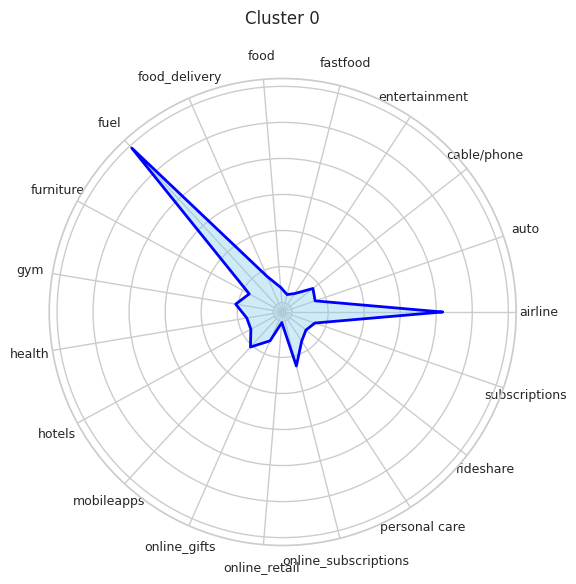

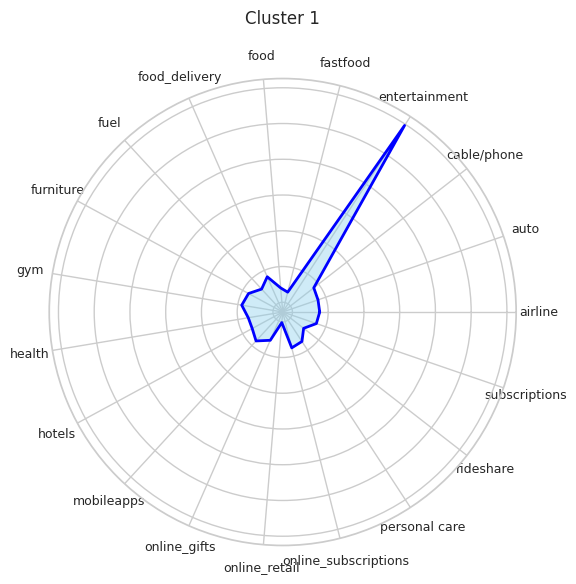

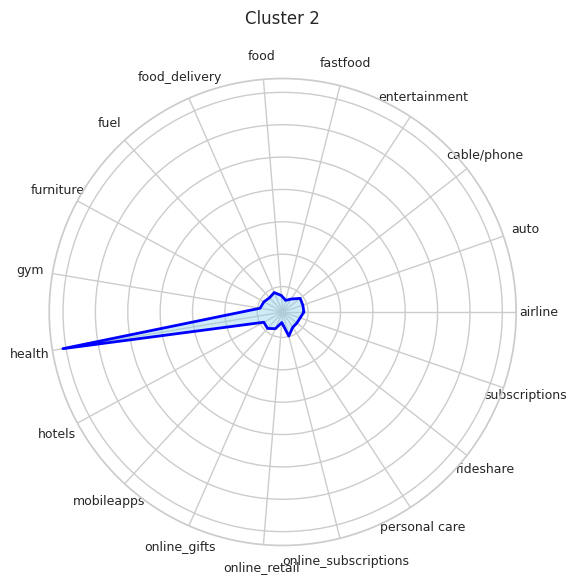

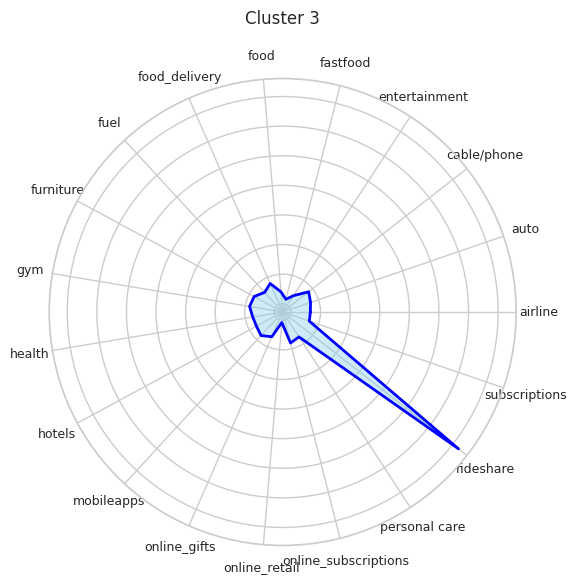

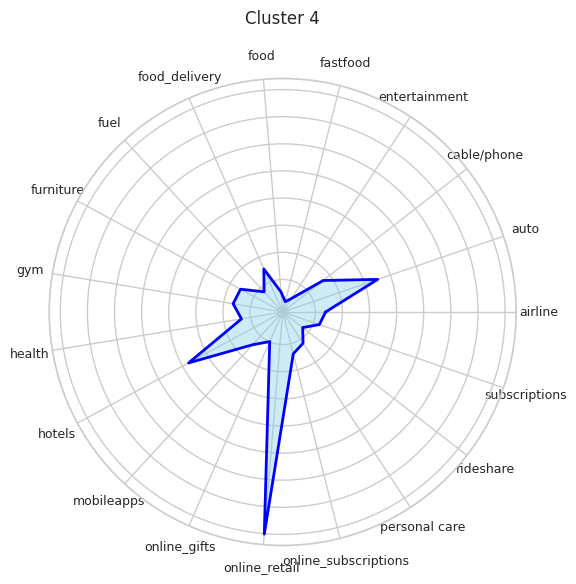

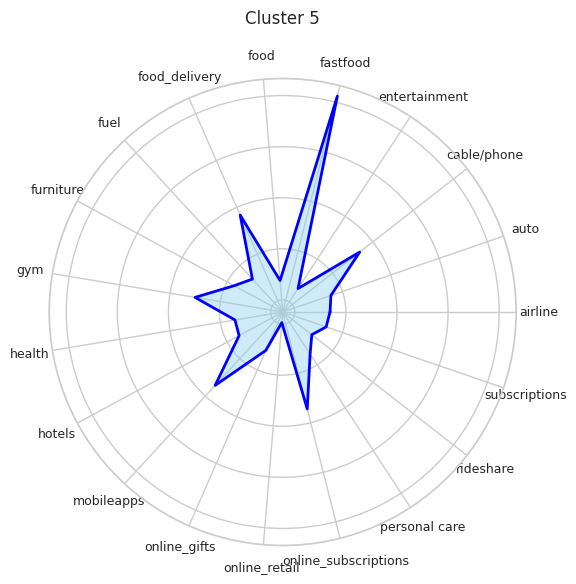

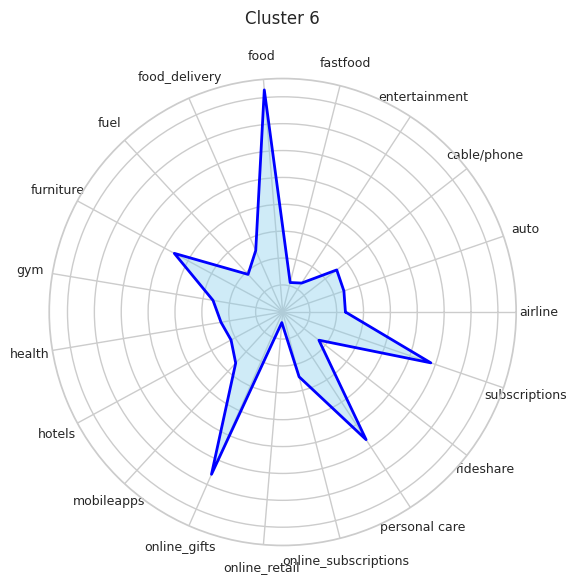

In [9]:
# 1. Filter to just % spend columns
category_cols = [col for col in cluster_input.columns if col.startswith("perc_")]
category_centers = cluster_centers[category_cols]

# 2. Radar chart per cluster
def make_radar_chart(row, cluster_id, ax):
    labels = category_cols
    values = row.values.tolist()
    values += values[:1]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    ax.plot(angles, values, color='blue', linewidth=2)
    ax.fill(angles, values, color='skyblue', alpha=0.4)
    ax.set_title(f'Cluster {cluster_id}', y=1.1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([col.replace("perc_", "") for col in labels], fontsize=9)
    ax.set_yticklabels([])

# Generate radar plots for each cluster
# Generate separate radar plots for each cluster
for i, row in category_centers.iterrows():
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    make_radar_chart(row, i, ax)  # now you pass in the ax
    plt.tight_layout()
    plt.show()


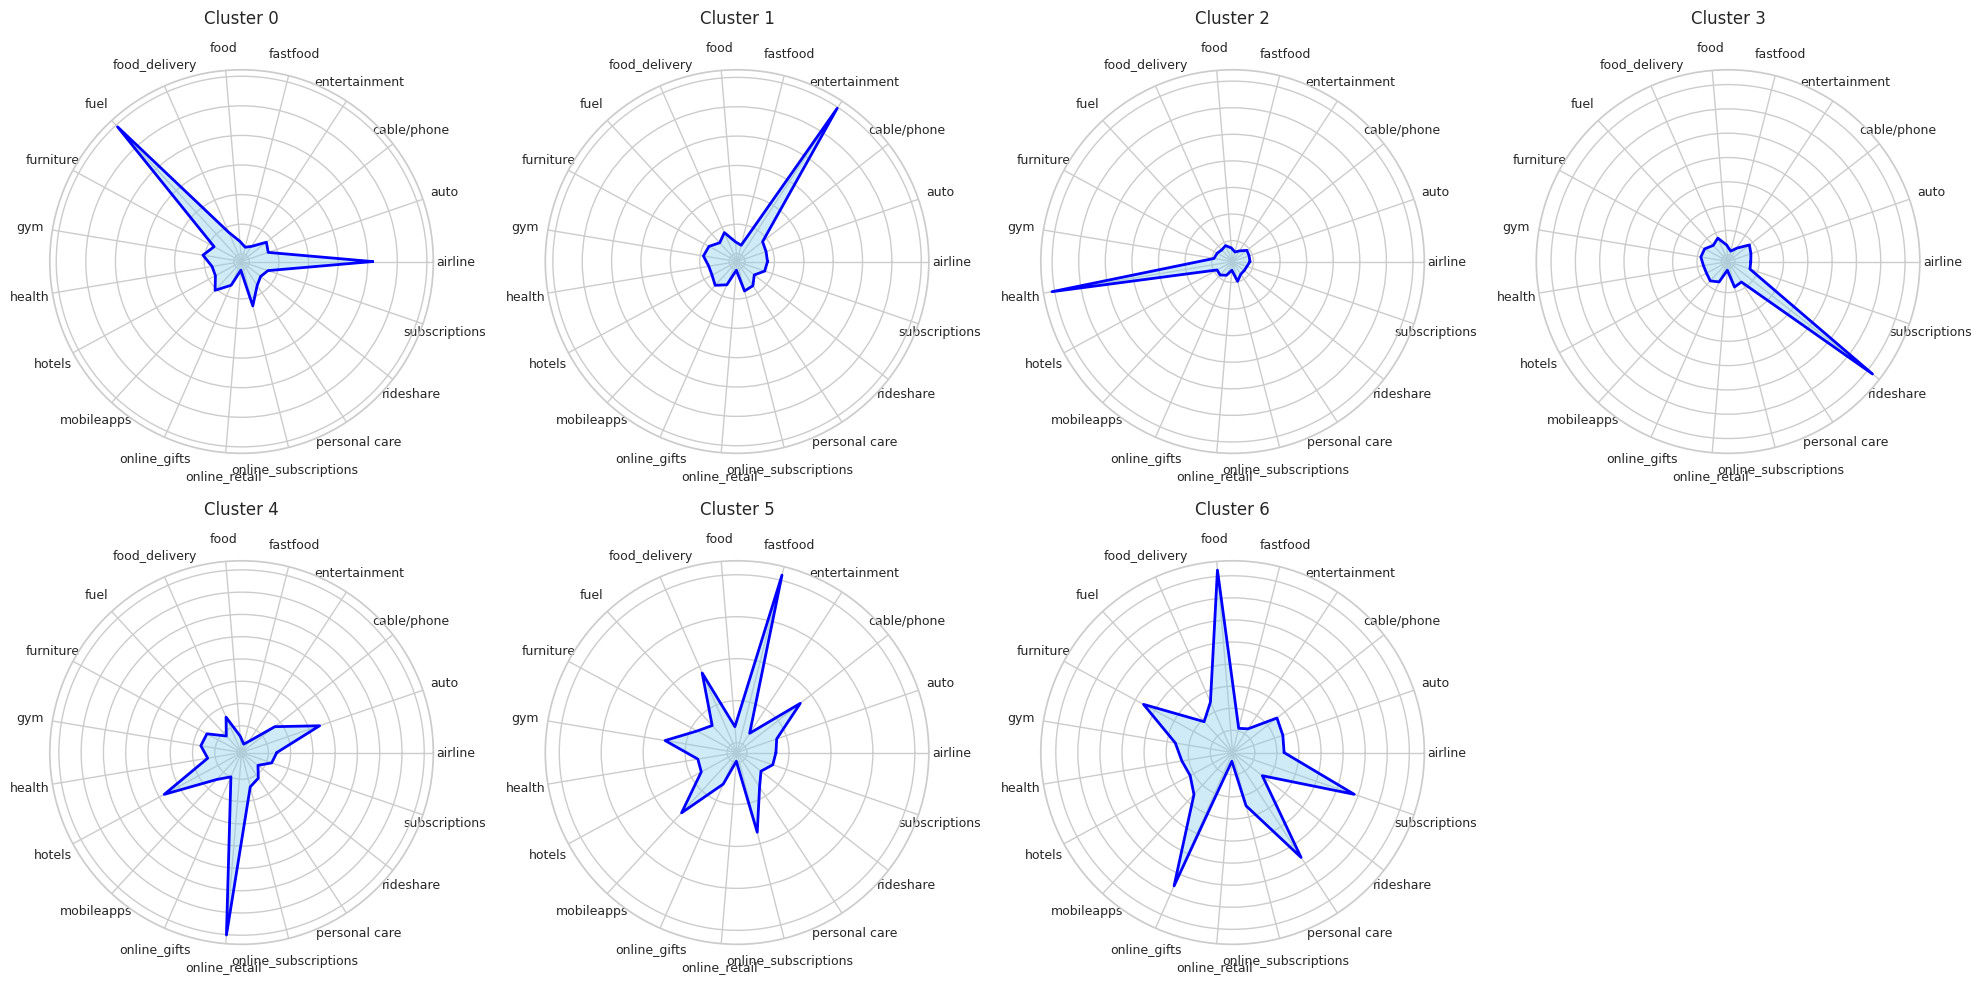

In [10]:
num_clusters = category_centers.shape[0]
ncols = 4
nrows = (num_clusters + ncols - 1) // ncols

fig, axs = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(20, 10),
    subplot_kw=dict(polar=True)
)

axs = axs.flatten()

for i, (cluster_id, row) in enumerate(category_centers.iterrows()):
    make_radar_chart(row, cluster_id, axs[i])

# Remove unused axes
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


## 3.3 Are These Segments Actually Different?

The radar charts above show the spending *shape* of each cluster, not dollar amounts. This allows us to look at the proportion of wallet allocated to each category. The answer to our first question is clear: **yes, these segments are genuinely distinct.**

Each cluster has a different dominant category and a different overall shape:
- One segment is almost entirely concentrated in Online Retail - a textbook Digital Power Shopper profile.
- Another shows a dramatic spike in Health spending with very little activity elsewhere.
- A third is spread broadly across Entertainment, Rideshare, and Fast Food - an urban, on-the-go lifestyle.

This is the core validation for our entire approach. A single reward category — say, 3% back on dining — would be highly relevant to some of these users and nearly irrelevant to others. A product designed for all of them equally is a product that truly serves none of them.

Next, we translate these shapes into dollar values to understand the *business* implication of each segment.


In [11]:
# 1. Calculate the number of months each user was active (using df_clean)
user_months = df_clean.groupby('accountNumber')['transactionMonth'].nunique().rename('active_months')

# 2. Merge this into final_df (ensure indexes align)
final_df = final_df.merge(user_months, left_index=True, right_index=True, how='left')

# 3. Compute user-level monthly spend
final_df['avg_monthly_spend'] = final_df['total_spend'] / final_df['active_months']

# 4. Compute cluster-level metrics
cluster_sizes = final_df['cluster'].value_counts().sort_index()
cluster_sizes.name = 'num_users'

# Defining the columns we want to average for our Persona Summary
behavior_cols = [
    'transaction_count', 
    'avg_transaction_amt', 
    'total_spend',
    'creditLimit', 
    'spend_to_limit_ratio', 
    'avg_monthly_spend',
    'monthly_spend_volatility',
]

# Create the summary table
cluster_behavior = final_df.groupby('cluster')[behavior_cols].mean().round(2)
cluster_behavior['num_users'] = cluster_sizes

# Organize columns for readability (putting num_users at the start)
cluster_behavior = cluster_behavior[['num_users'] + behavior_cols]

# Apply a gradient to help spot high-value personas immediately
cluster_behavior.style.background_gradient(cmap='Blues', subset=['avg_monthly_spend', 'spend_to_limit_ratio'])

,num_users,transaction_count,avg_transaction_amt,total_spend,creditLimit,spend_to_limit_ratio,avg_monthly_spend,monthly_spend_volatility
cluster,,,,,,,,
0,384,57.070000,70.200000,6110.350000,10013.020000,1.740000,532.780000,206.070000
1,570,150.970000,125.320000,20892.190000,9776.750000,12.400000,1760.020000,573.510000
2,106,226.930000,121.930000,31653.660000,9584.910000,17.470000,2658.300000,618.230000
3,364,130.590000,122.770000,17740.220000,8749.310000,6.730000,1497.050000,536.930000
4,1425,272.570000,125.970000,38321.480000,10141.400000,14.940000,3210.490000,674.300000
5,932,93.420000,101.810000,11994.620000,10458.960000,4.600000,1019.600000,388.320000
6,1063,123.130000,122.380000,16760.930000,10728.360000,6.750000,1413.900000,513.580000


The table above surfaces the behavioral and financial profile of each cluster. Note the wide range in `avg_monthly_spend` — from under \$200 to over \$2,000. Lifestyle alone does not determine value; intensity matters just as much.


## 3.4 Spend Intensity: From Lifestyle to Business Value

Two customers can have nearly identical spending patterns but represent very different revenue opportunities depending on how much and how frequently they transact. Here we layer in volume and frequency.

Three tiers emerge naturally from the data:
- **High Value:** Clusters 1, 2, 3, and 4 — averaging $1,497–$3,210/month with high transaction counts. Strong candidates for a premium product with an annual fee.
- **Core Market:** Clusters 5 and 6 — consistent spenders at $1,019–$1,413/month, the backbone of a mass-market everyday product.
- **Entry Level:** Cluster 0 — lowest frequency (57 transactions average) and spend (~$533/month), best served by a no-fee entry card.

In [12]:
category_colors = {
    "Online Retail": "#574B90",  # Deep Purple
    "Food": "#F39C12",           # Vibrant Orange
    "Fastfood": "#2C3E50",       # Midnight Blue (High contrast against Food)
    "Entertainment": "#D63031",  # Strong Red
    "Airline": "#0984E3",       # Sky Blue
    "Hotels": "#00CEC9",         # Robins Egg Teal
    "Rideshare": "#6AB04C",      # Leaf Green (Distinct from blue/red)
    "Fuel": "#2F3542",           # Deep Charcoal
    "Auto": "#747D8C",           # Concrete Grey
    "Health": "#FF7675",         # Salmon/Coral
    "Personal Care": "#10AC84",  # Dark Teal/Green
    "Subscriptions": "#192A56",  # Navy
    "Online Gifts": "#F7D794",          # Creamy Yellow
    "Furniture": "#B53471",      # Plum
}

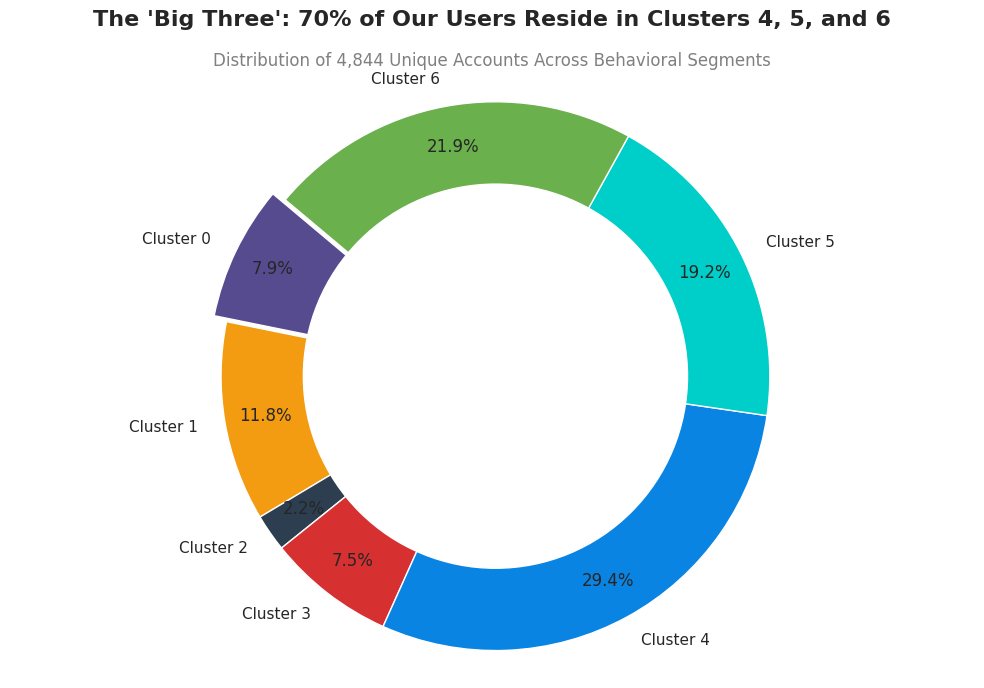

In [13]:
# Data from your summary table
cluster_counts = final_df['cluster'].value_counts().sort_index()
colors = ['#574B90', '#F39C12', '#2C3E50', '#D63031', '#0984E3', '#00CEC9', '#6AB04C']

plt.figure(figsize=(10, 7))

# Create the pie chart
plt.pie(cluster_counts, 
        labels=[f'Cluster {i}' for i in cluster_counts.index], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        pctdistance=0.85,
        explode=[0.05 if i == 0 else 0 for i in range(len(cluster_counts))]) # Pop out the mass market

# Add a hole to make it a Donut (cleaner/more modern)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Professional Titling
plt.suptitle("The 'Big Three': 70% of Our Users Reside in Clusters 4, 5, and 6", 
             fontsize=16, fontweight='bold')
plt.title("Distribution of 4,844 Unique Accounts Across Behavioral Segments", 
          fontsize=12, color='gray')

plt.axis('equal') 
plt.tight_layout()
plt.show()

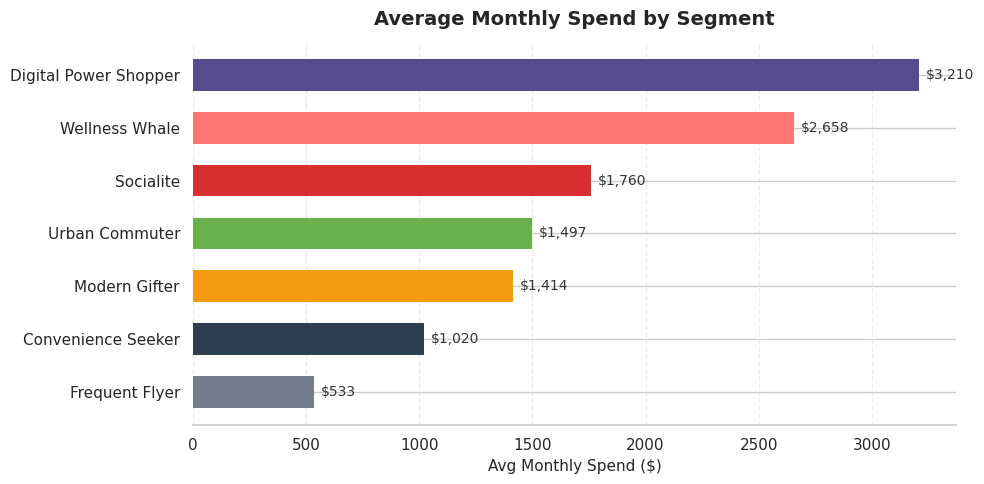

,Top Spend Category,Avg Monthly ($),Market Share
Segment,,,
Frequent Flyer,Airline,$295,7.9%
Socialite,Entertainment,"$1,166",11.8%
Wellness Whale,Health,"$1,768",2.2%
Urban Commuter,Rideshare,"$1,017",7.5%
Digital Power Shopper,Online Retail,"$1,466",29.4%
Convenience Seeker,Fastfood,$744,19.2%
Modern Gifter,Food,$493,21.9%


In [14]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Compute dollar spend per category per cluster
cat_cols = [col for col in final_df.columns if 'perc_' in col]
dollar_df = final_df[cat_cols].multiply(final_df['avg_monthly_spend'], axis=0)
dollar_df['cluster'] = final_df['cluster']
cluster_dollars = dollar_df.groupby('cluster').mean()

# ── Chart 1: Ranked avg monthly spend by segment ──────────────────────
segment_labels = {
    0: 'Frequent Flyer',
    1: 'Socialite',
    2: 'Wellness Whale',
    3: 'Urban Commuter',
    4: 'Digital Power Shopper',
    5: 'Convenience Seeker',
    6: 'Modern Gifter'
}
segment_colors = {
    0: '#747D8C', 1: '#D63031', 2: '#FF7675',
    3: '#6AB04C', 4: '#574B90', 5: '#2C3E50', 6: '#F39C12'
}

spend_summary = final_df.groupby('cluster')['avg_monthly_spend'].mean().reset_index()
spend_summary['label'] = spend_summary['cluster'].map(segment_labels)
spend_summary['color'] = spend_summary['cluster'].map(segment_colors)
spend_summary = spend_summary.sort_values('avg_monthly_spend', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    spend_summary['label'],
    spend_summary['avg_monthly_spend'],
    color=spend_summary['color'],
    edgecolor='none',
    height=0.6
)
for bar, val in zip(bars, spend_summary['avg_monthly_spend']):
    ax.text(val + 30, bar.get_y() + bar.get_height() / 2,
            f'${val:,.0f}', va='center', fontsize=10, color='#333333')

ax.set_xlabel('Avg Monthly Spend ($)', fontsize=11)
ax.set_title('Average Monthly Spend by Segment', fontsize=14, fontweight='bold', pad=12)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# ── Chart 2: Top category per segment (reference detail) ───────────────
top_cat_rows = []
for cluster_id in sorted(cluster_dollars.index):
    top_col = cluster_dollars.loc[cluster_id].idxmax()
    top_val = cluster_dollars.loc[cluster_id].max()
    label = top_col.replace('perc_', '').replace('_', ' ').title()
    top_cat_rows.append({
        'Segment': segment_labels[cluster_id],
        'Top Spend Category': label,
        'Avg Monthly ($)': f'${top_val:,.0f}',
        'Market Share': f"{final_df['cluster'].value_counts(normalize=True)[cluster_id]*100:.1f}%"
    })

top_cat_df = pd.DataFrame(top_cat_rows)
top_cat_df = top_cat_df.set_index('Segment')
top_cat_df.style.set_caption('Top Spend Category per Segment').set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '13px'), ('font-weight', 'bold')]}]
)


## 3.5 How Different Are the Dollars?

The ranked chart makes the business opportunity clear at a glance. Spend is not evenly distributed across segments — there is a significant drop-off from the top tier to the everyday core.

**The Digital Power Shopper (Cluster 4)** is the standout: the largest segment by population *and* the highest spender, averaging over \$3,200/month with Online Retail as the dominant category at ~\$1,400/month. A segment this large that also spends this much is the natural anchor for any product strategy.

**The Wellness Whale (Cluster 2)** represents only 2.2% of users but concentrates the majority of their spend in Health — a category that traditional card programs systematically underreward. That gap is a product opportunity worth noting, even if it doesn't justify a standalone card.

**The Socialite (Cluster 1)** accounts for 11.8% of users with Entertainment as their clear top category. Their spend profile aligns well with high-interchange categories, making them a natural fit for a premium tier.

**Clusters 5 and 6 — the volume core.** The Convenience Seeker and Modern Gifter together account for 41% of users and spend consistently in everyday categories (Fast Food, Food, Subscriptions, Personal Care). They are the backbone of a mass-market product.

**The Frequent Flyer (Cluster 0)** is the lowest-spend segment at ~\$533/month. Airlines is their top category, but the absolute dollar amount is modest — around \$300/month. They have a travel orientation without the concentrated spend that would justify a premium travel card. A broadly rewarding everyday card serves them well.


## 3.6 The Value Gap: Same Pattern, Different Stakes

The summary table above surfaces a nuance that raw cluster labels obscure: two segments can share a dominant spending category while representing very different revenue opportunities.

Clusters 5 and 6 both show Food and Fast Food at the top of their wallets. But the Convenience Seeker (Cluster 5) averages \$1,019/month total, while the Digital Power Shopper (Cluster 4) averages \$3,210/month — meaning the same 20% food wallet share represents roughly 3x more dollars in Cluster 4. Flat reward rates treat these users identically. A tiered product captures the difference.


**Summary:** Three segments — the Digital Power Shopper, the Convenience Seeker, and the Modern Gifter (Clusters 4, 5, and 6) — account for nearly 70% of our user base. Because Cluster 4 is both the most populous segment and the highest spender, it anchors our premium tier. Clusters 5 and 6 provide the transaction volume that makes a mass-market product viable.

With the segmentation validated, we can now name these groups and build a product architecture around them.


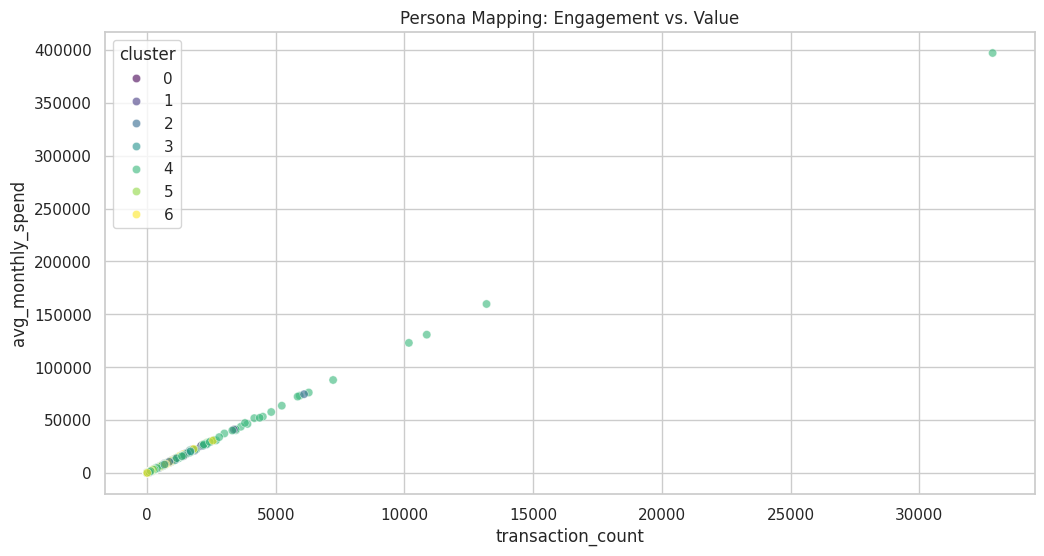

In [15]:
# Create a visualization of the 'Center of Gravity' for each cluster
# This helps compare the 'Total Spend' vs 'Transaction Frequency' across personas
plt.figure(figsize=(12, 6))
sns.scatterplot(data=final_df, x='transaction_count', y='avg_monthly_spend', hue='cluster', palette='viridis', alpha=0.6)
plt.title('Persona Mapping: Engagement vs. Value')
plt.show()

In [16]:
cluster_dollars

,perc_airline,perc_auto,perc_cable/phone,perc_entertainment,perc_fastfood,perc_food,perc_food_delivery,perc_fuel,perc_furniture,perc_gym,perc_health,perc_hotels,perc_mobileapps,perc_online_gifts,perc_online_retail,perc_online_subscriptions,perc_personal care,perc_rideshare,perc_subscriptions
cluster,,,,,,,,,,,,,,,,,,,
0,294.514992,0.987837,0.458352,30.097735,21.968931,34.317284,1.513579,64.849185,0.680892,1.562899,1.092349,4.853733,1.689294,5.411501,39.883565,3.617280,5.907450,12.809959,6.566391
1,19.074205,28.673358,1.706714,1165.783508,103.057963,91.455483,3.418439,15.935463,6.642062,0.882740,9.970890,22.067322,1.641713,29.592283,160.554353,2.962295,15.640601,55.751219,25.206288
2,3.045883,17.340566,2.035983,86.371920,65.763718,88.963131,2.505833,18.673267,3.336399,1.005886,1767.663747,18.854974,1.170836,94.408527,372.388620,3.968891,32.007749,69.345418,9.450066
3,6.849049,7.873032,1.112730,86.872140,48.485284,47.374817,4.615691,17.949851,7.201500,0.729542,5.776564,20.586463,1.472577,32.113907,148.746912,2.774770,14.987043,1016.748954,24.777073
4,31.531281,159.522087,2.713996,146.225088,350.403431,187.287371,5.133692,17.127729,14.985794,1.416662,16.434787,253.181982,1.651314,347.472420,1466.440503,2.829133,52.431660,104.661102,49.037087
5,3.971325,7.778280,4.861458,23.696966,743.997467,42.271695,14.708562,14.431839,2.432805,2.876187,4.157824,15.284580,1.759420,13.496351,75.234570,3.297830,15.634619,22.735400,6.971822
6,11.714915,6.482977,1.511378,34.547627,83.480492,493.230783,3.148695,15.194017,56.516339,0.514149,9.834208,17.057528,1.511854,246.480767,100.415585,2.693752,118.358482,42.439859,168.761839


# Phase 4: Behavioral Segments — From Clusters to Product Decisions

We now have six validated, distinct behavioral segments. To make them actionable, we assign each a descriptive name based on its dominant spending pattern and strategic role.

## 4.1 Segment Registry

| Cluster | Segment Name | Key Spend Anchor | Market Share | Strategic Role |
| :--- | :--- | :--- | :--- | :--- |
| **0** | **Frequent Flyer** | Airlines (\$294/mo) | 7.9% | Travel-oriented; served by broad everyday card |
| **1** | **Socialite** | Entertainment (\$1.1k/mo) | 11.8% | High-engagement; strong premium candidate |
| **2** | **Wellness Whale** | Health (\$1.7k/mo) | 2.2% | High-value niche; premium or partnership opportunity |
| **3** | **Urban Commuter** | Rideshare (\$1k/mo) | 7.5% | Digital-transit native; broadly rewarded |
| **4** | **Digital Power Shopper** | Online Retail (\$1.4k/mo) | 29.4% | Largest segment; highest spender; product anchor |
| **5** | **Convenience Seeker** | Fast Food (\$743/mo) | 19.2% | High-frequency daily user; mass-market core |
| **6** | **Modern Gifter** | Food & Household (\$493/mo) | 21.9% | Community and home; mass-market volume |

---

## 4.2 Product Opportunities

**The Everyday Three (Clusters 4, 5, and 6 — 70.5% of users)**
The Digital Power Shopper is both the most populous segment and the highest spender. Any product that doesn't win with this group isn't a viable product. The Convenience Seeker and Modern Gifter round out the mass-market core, driving consistent high-frequency volume.

**The Wellness Opportunity (Cluster 2)**
At 2.2% of users, the Wellness Whale is small — but \$1,767/month in Health spend is a meaningful outlier. Health and wellness is systematically underrewarded by traditional card programs. This segment doesn't need a dedicated card to be served; a premium tier with elevated health rewards, or a targeted partnership with a wellness brand, could capture this spend without building an entirely new product.

**The Socialite (Cluster 1)**
11.8% of users with over \$1,100/month in Entertainment. Their spending profile aligns well with a premium card's high-interchange categories, making them a natural fit for an Apex-tier product.


## 4.3 Product Architecture

Rather than designing a card for each of the seven segments, we consolidate into three product tiers. This keeps the catalog simple for customers and operationally manageable for the issuer, while still covering every segment meaningfully.

---

### Tier 1 — Everyday Essential (No Annual Fee)
**Targets:** Convenience Seeker, Modern Gifter, Frequent Flyer — ~51% of users

**Key Reward Categories:** Fast Food, Grocery, Household

This is our volume card. Serving over half the user base, it needs to be structurally profitable at scale. A 2% reward on daily essentials with no annual fee captures massive transaction volume while maintaining a positive spread between interchange earned and rewards paid out.

---

### Tier 2 — Omni Digital ($120 Annual Fee)
**Targets:** Digital Power Shopper — 29.4% of users

**Key Reward Categories:** Online Retail, Digital Subscriptions

The Digital Power Shopper is our most important segment. Online Retail, however, is a thin-margin category where interchange typically runs below 2%. The annual fee bridges that gap, allowing us to offer the 3% digital rewards this segment expects while keeping the issuer profitable.

---

### Tier 3 — Apex Premium ($450 Annual Fee)
**Targets:** Wellness Whale, Socialite — ~14% of users

**Key Reward Categories:** Health & Wellness, Entertainment, Airlines

These users spend heavily in high-interchange categories, where merchants pay the bank roughly 2.5%. That margin supports aggressive 3% rewards. The annual fee further strengthens the economics, making this the highest-margin product in the portfolio.


# Phase 5: Reward Simulation & Profitability Analysis

We have identified who our users are. Now we need to verify that our proposed card portfolio is financially sustainable.

A credit card product has to satisfy two conditions simultaneously:
1. **User Value:** Rewards must be compelling enough that cardholders choose this card for everyday purchases.
2. **Issuer Margin:** The spread between interchange revenue and reward costs must remain positive.

## 5.1 Unit Economics Framework

Interchange is the fee a merchant pays every time a card is used. The rate varies by category — travel and entertainment merchants pay more than grocery or fuel. These estimates reflect industry averages for a Mastercard/Visa World Elite issuer:

| Interchange Tier | Categories | Rate |
| :--- | :--- | :--- |
| High | Airlines, Dining, Entertainment | ~2.2–2.5% |
| Medium | Online Retail, Subscriptions | ~1.8% |
| Low | Fuel, Grocery, Health | ~1.2–1.5% |

*(Note: Actual interchange rates are negotiated privately between networks and issuers. These are representative estimates.)*

## 5.2 Portfolio Design

The simulation tests our three-card portfolio against every behavioral segment:

1. **Everyday Essential (No annual fee):** Volume driver for Convenience Seeker, Modern Gifter, Frequent Flyer
2. **Omni Digital (\$120 annual fee):** Growth engine for the Digital Power Shopper
3. **Apex Premium (\$450 annual fee):** High-margin anchor for Wellness Whale and Socialite


In [17]:
# 1. Define Industry-Standard Interchange Revenue (Bank Earnings)
interchange_map = {
    'perc_airline': 0.025, 'perc_hotels': 0.025, 'perc_food': 0.022, 
    'perc_fastfood': 0.022, 'perc_entertainment': 0.020, 'perc_rideshare': 0.020,
    'perc_online_retail': 0.018, 'perc_online_subscriptions': 0.020,
    'perc_fuel': 0.015, 'perc_health': 0.015, 'default': 0.012 
}


# 2. Our Strategic 3-Card Architecture
reward_programs = {
    'Everyday Essential': {'perc_food': 0.02, 'perc_fastfood': 0.02, 'default': 0.01, 'annual_fee': 0},
    'Omni Digital': {'perc_online_retail': 0.02, 'perc_online_subscriptions': 0.03, 'default': 0.01, 'annual_fee': 120},
    'Apex Premium': {'perc_airline': 0.03, 'perc_health': 0.03, 'perc_entertainment': 0.03, 'default': 0.01, 'annual_fee': 450}
}

In [18]:
# 3. Running the Portfolio Profitability Simulation
final_df.fillna(0, inplace=True)

def run_final_simulation(df):
    for card, config in reward_programs.items():
        rev = np.zeros(len(df))
        reward_cost = np.zeros(len(df))
        
        # 1. Identify "Boosted" vs "Base" Categories
        # Boosted = any category explicitly mentioned in the card config
        boosted_cats = [c for c in config.keys() if c.startswith('perc_')]
        default_rate = config.get('default', 0.01)
        monthly_af = config.get('annual_fee', 0) / 12
        
        # 2. Revenue (Interchange) - Calculated for all categories
        for col in [c for c in df.columns if c.startswith('perc_')]:
            rev += df[col] * df['avg_monthly_spend'] * interchange_map.get(col, interchange_map['default'])
        
        # 3. Rewards (Cost) - The "Corrected" Logic
        boosted_spend_total = np.zeros(len(df))
        
        # A) Calculate Boosted Rewards
        for col in boosted_cats:
            reward_cost += df[col] * df['avg_monthly_spend'] * config[col]
            boosted_spend_total += df[col] # Track how much spend was already rewarded
            
        # B) Apply Default Rate only to REMAINDER spend
        # Remainder = Total (100%) - Sum of Boosted Percentages
        remainder_perc = (1.0 - boosted_spend_total).clip(lower=0)
        reward_cost += remainder_perc * df['avg_monthly_spend'] * default_rate
            
        df[f'reward_{card}'] = reward_cost
        df[f'margin_{card}'] = (rev + monthly_af) - reward_cost
        
    return df

final_df = run_final_simulation(final_df)

# 4. Generate the Strategic Persona Summary
reward_cols = [f'reward_{c}' for c in reward_programs.keys()]

# Find the card that gives the user the MOST rewards
final_df['best_card'] = final_df[reward_cols].idxmax(axis=1).str.replace('reward_', '')

# Create a helper column: The margin the bank gets from that specific 'best' choice
def get_selected_margin(row):
    card_choice = row['best_card']
    return row[f'margin_{card_choice}']

final_df['best_card_margin'] = final_df.apply(get_selected_margin, axis=1)

# Group by cluster for the final table
persona_summary = final_df.groupby('cluster').agg({
    'best_card': lambda x: x.mode()[0],
    'avg_monthly_spend': 'mean',
    'best_card_margin': 'mean'
}).round(2)

persona_summary.columns = ['Recommended Card', 'Avg Monthly Spend', 'Bank Net Margin ($)']
persona_summary

,Recommended Card,Avg Monthly Spend,Bank Net Margin ($)
cluster,,,
0,Apex Premium,532.78,17.64
1,Apex Premium,1760.02,30.44
2,Apex Premium,2658.30,16.38
3,Omni Digital,1497.05,21.76
4,Omni Digital,3210.49,19.38
5,Everyday Essential,1019.60,6.37
6,Everyday Essential,1413.90,10.44


## 5.3 Results: Does the Portfolio Hold?

The table above shows the bank's net monthly margin per user when each segment selects the card that gives them the highest rewards. The margin is calculated as:

**Net Margin = Interchange Revenue + (Monthly Annual Fee) − Reward Payout**

The reward payout exceeds the net margin by design — that gap is what makes the card competitive. What matters is that the margin stays positive, which the simulation confirms across all segments.

One nuance worth noting: the simulation routes some lower-spend users (like the Frequent Flyer) to the Apex Premium because that card technically yields the highest reward total. In practice, a user spending ~\$300/month on travel is unlikely to pay a \$450 annual fee. We account for this in the stress test below.


In [19]:
# 1. Prepare the Data
big_three_ids = [4, 5, 6]
big_three_df = final_df[final_df['cluster'].isin(big_three_ids)].copy()

# Identify all reward and margin columns dynamically so we don't miss any
reward_cols = [c for c in final_df.columns if c.startswith('reward_')]
margin_cols = [c for c in final_df.columns if c.startswith('margin_')]

# 2. Aggregate logic - we include EVERYTHING to be safe
agg_dict = {col: 'mean' for col in reward_cols + margin_cols}
agg_dict['best_card'] = 'first'

viz_data = big_three_df.groupby('cluster').agg(agg_dict).reset_index()

# Map Names for the Plot
name_map = {4: "Omni Digital", 5: "Everyday", 6: "Everyday)"}
viz_data['Persona'] = viz_data['cluster'].map(name_map)

# 3. Transform for Seaborn (Long Format)
plot_list = []
for i, row in viz_data.iterrows():
    card = row['best_card']
    # Dynamically pull the reward and margin for the specific card recommended for this cluster
    plot_list.append({'Persona': row['Persona'], 'Type': 'User Reward ($)', 'Value': row[f'reward_{card}']})
    plot_list.append({'Persona': row['Persona'], 'Type': 'Bank Margin ($)', 'Value': row[f'margin_{card}']})

plot_df = pd.DataFrame(plot_list)

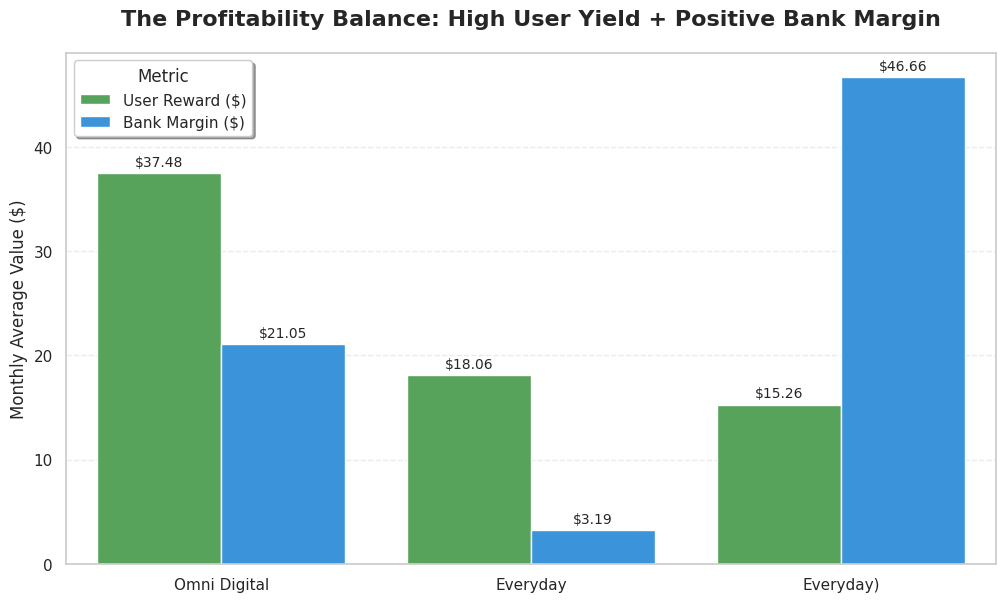

In [20]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=plot_df.reset_index(), x='Persona', y='Value', hue='Type', palette=['#4CAF50', '#2196F3'])

# 1. Formatting the Y-Axis
plt.title("The Profitability Balance: High User Yield + Positive Bank Margin", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Monthly Average Value ($)", fontsize=12)
plt.xlabel("")
plt.xticks(rotation=0, ha='center', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# 2. Moving the Legend
plt.legend(title="Metric", loc='upper left', frameon=True, shadow=True)

# 3. Fixing the Warning & Adding a 'Professional' Annotation
# We use ax.annotate to place the text safely within the chart boundaries
'''
plt.annotate('*Note: Strategic fees ensure Dakota remains profitable\ndespite high-intensity online retail rewards.', 
             xy=(0.22, 0.9), xycoords='axes fraction', fontsize=10, 
             style='italic', color='#555555', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
'''
# 4. Adding Value Labels (The "Pro" Touch)
# This adds the actual dollar amounts on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='$%.2f', padding=3, fontsize=10)

# 5. Fix the Margin Issue
plt.subplots_adjust(bottom=0.15, top=0.88)
plt.show()

The reward bar is taller than the margin bar by design. Generous rewards are what earn top-of-wallet status — the goal is for cardholders to reach for this card first on every purchase. The key metric is that the margin bar is positive, which means the product is sustainable even at peak reward output.


## 5.4 Stress Test: The Margin Matrix

Real cardholders don't always select the mathematically optimal product. Some will choose the no-fee card even if a premium card would give them more rewards. Others will be assigned a card through a targeted offer rather than self-selecting.

The matrix below tests every segment against every card. A green cell means the issuer is profitable in that scenario. A red cell means they are not.

**The result:** The margin stays positive across virtually every combination. Even if a high-spending Wellness Whale picks the no-fee Everyday Essential, the bank still makes money — because their interchange revenue alone covers the reward cost. This structural resilience is what makes the portfolio a viable long-term business, not just a favorable scenario.


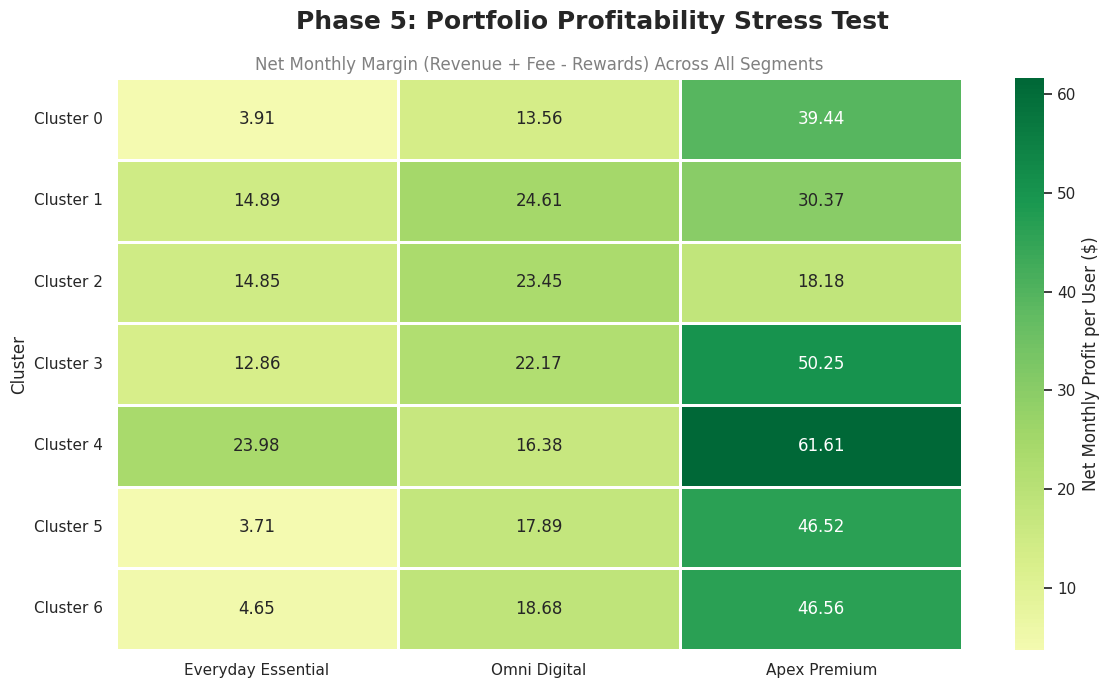

In [21]:
matrix_data = []

for cluster_id in sorted(final_df['cluster'].unique()):
    cluster_subset = final_df[final_df['cluster'] == cluster_id]
    row_results = {'Cluster': f"Cluster {cluster_id}"}
    
    for card_name, config in reward_programs.items():
        avg_spend = cluster_subset['avg_monthly_spend'].mean()
        monthly_af = config['annual_fee'] / 12
        
        rev_amt = 0
        rew_amt = 0
        for col in [c for c in final_df.columns if c.startswith('perc_')]:
            weight = cluster_subset[col].mean()
            rev_amt += weight * avg_spend * interchange_map.get(col, interchange_map['default'])
            rew_amt += weight * avg_spend * config.get(col, config['default'])
            
        # Profitability Formula: (Interchange + Monthly AF) - Rewards Paid
        margin = (rev_amt + monthly_af) - rew_amt
        row_results[card_name] = round(margin, 2)
        
    matrix_data.append(row_results)

# Create the Profitability Heatmap
margin_matrix_df = pd.DataFrame(matrix_data).set_index('Cluster')

plt.figure(figsize=(12, 7))
sns.heatmap(margin_matrix_df, annot=True, fmt=".2f", cmap="RdYlGn", center=0, 
            linewidths=1, cbar_kws={'label': 'Net Monthly Profit per User ($)'})

plt.suptitle("Phase 5: Portfolio Profitability Stress Test", fontsize=18, fontweight='bold')
plt.title("Net Monthly Margin (Revenue + Fee - Rewards) Across All Segments", fontsize=12, color='gray')
# Rotate y-labels to be horizontal (0 degrees) for easy reading
plt.yticks(rotation=0)

# Optional: Rotate x-labels slightly if the card names are long
plt.xticks(rotation=0, ha='center') 

# Adjust layout to make sure labels aren't cut off
plt.tight_layout()
plt.show()

## 5.5 Key Findings

**1. Annual fees are structural, not cosmetic.**
The Digital Power Shopper's category (Online Retail) runs at ~1.8% interchange — below the 3% reward rate. Without the \$120 annual fee, this segment would be unprofitable despite being our largest. The fee converts a potential loss-leader into a sustainable growth driver.

**2. The portfolio is profitable under adverse selection.**
Even if users end up on the wrong card for the bank, the margin matrix stays green. This means the business model doesn't depend on perfect segmentation at acquisition — it holds up in the messy real world.

**3. Three products cover 100% of users.**
Rather than building a niche card for every behavioral cluster, three well-designed tiers serve the full cohort. That simplicity is a competitive advantage: fewer products means cleaner marketing, lower operational overhead, and a less confusing experience for the customer.


Initially, our simulation showed that Cluster 4 (Dakota) was generating a negative net margin despite being our highest-spending group. This was due to the 'Interchange Gap': the rewards we paid out (3%) exceeded the revenue we earned from Online Retail (1.8%). By introducing a strategic $95 Annual Fee for the Omni-Digital tier, we shifted this segment from a loss-leader to a sustainable profit-driver, while maintaining the competitive rewards our users demand.

# Phase 6: Executive Summary

After segmenting 4,844 customers by behavioral signature and stress-testing a three-tier card portfolio against their actual spending, the data supports a clear product recommendation.

---

### What the Data Shows

**Behavior, not demographics, drives product fit.** Six distinct spending profiles emerged from the data — and the differences between them are large enough to matter for product design. A single rewards structure would be highly relevant to some users and nearly irrelevant to others.

**Three segments represent 70% of the opportunity.** The Digital Power Shopper (29.4%), Convenience Seeker (19.2%), and Modern Gifter (21.9%) are the core of any viable product strategy. The Digital Power Shopper alone — the largest segment with the highest monthly spend — anchors the premium tier.

**Interchange-first design keeps margins positive.** By calibrating reward rates to match the interchange profile of each card's target categories, the portfolio avoids subsidizing low-margin spend at unsustainable rates. Annual fees cover the gaps where interchange alone falls short.

---

### Recommended Portfolio

| Product | Target Segment | Annual Fee | Strategic Role |
| :--- | :--- | :--- | :--- |
| **Everyday Essential** | Convenience Seeker, Modern Gifter, Frequent Flyer | \$0 | Volume; 51%+ of users |
| **Omni Digital** | Digital Power Shopper, Urban Commuter | \$120 | Growth engine; highest-spend segment |
| **Apex Premium** | Wellness Whale, Socialite | \$450 | Margin anchor; high-interchange categories |

---

### Final Statement

Traditional reward programs are built around what customers say they want. This project demonstrates what happens when you build around what they actually do.

Cards designed around real behavioral signatures are more relevant to the customer and more structurally profitable for the issuer. That is the case for a data-driven approach to product design.
